# 02 — Network overview EDA
**AccessMap London** · TfL Station Accessibility Gap Analysis

**Goal:** Big-picture accessibility stats across the entire TfL network —
score distribution, band breakdown, and average score by fare zone.


## Setup — imports
*Run this first every time.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (12, 5)})

COLOURS = {
    'Good (70-100)':   '#1D9E75',
    'Partial (40-69)': '#EF9F27',
    'Poor (0-39)':     '#E24B4A',
}
BAND_ORDER = ['Good (70-100)', 'Partial (40-69)', 'Poor (0-39)']
PALETTE    = [COLOURS[b] for b in BAND_ORDER]

print('Libraries loaded ✓')

Libraries loaded ✓


## Load raw data
*Reads directly from `raw_data/` — no pre-processing.*

In [2]:
RAW = '../raw_data/'

stations     = pd.read_csv(RAW + 'Stations.csv')
lifts        = pd.read_csv(RAW + 'Lifts.csv')
platforms    = pd.read_csv(RAW + 'Platforms.csv')
platform_svc = pd.read_csv(RAW + 'PlatformServices.csv')
toilets      = pd.read_csv(RAW + 'Toilets.csv')
stn_points   = pd.read_csv(RAW + 'StationPoints.csv')
step_free    = pd.read_csv(RAW + 'StepFreeIntechangeInfo.csv')
ramp_routes  = pd.read_csv(RAW + 'RampRoutes.csv')
modes_lines  = pd.read_csv(RAW + 'ModesAndLines.csv')
feed_info    = pd.read_csv(RAW + 'FeedInfo.csv')

print('All raw files loaded ✓')
print(f'  Stations        : {len(stations):>4} rows')
print(f'  Lifts           : {len(lifts):>4} rows')
print(f'  Platforms       : {len(platforms):>4} rows')
print(f'  PlatformServices: {len(platform_svc):>4} rows')
print(f'  Toilets         : {len(toilets):>4} rows')
print(f'  StationPoints   : {len(stn_points):>4} rows')
print(f'  StepFreeInfo    : {len(step_free):>4} rows')
print(f'  RampRoutes      : {len(ramp_routes):>4} rows')

All raw files loaded ✓
  Stations        :  509 rows
  Lifts           :  569 rows
  Platforms       : 1584 rows
  PlatformServices: 1878 rows
  Toilets         :  410 rows
  StationPoints   : 4084 rows
  StepFreeInfo    :  114 rows
  RampRoutes      :  418 rows


## Clean data
*Fix boolean types, extract primary zone, normalise fields.*

In [3]:
def to_bool(s):
    return (s.astype(str).str.strip().str.upper()
             .map({'TRUE': True, 'FALSE': False, '1': True, '0': False, 'NAN': False})
             .fillna(False))

# Stations
st = stations.copy()
for col in ['Wifi','BlueBadgeCarParking','TaxiRanksOutsideStation',
            'MainBusInterchange','NationalRailInterchange','AirportInterchange']:
    if col in st.columns:
        st[col] = to_bool(st[col])
st['PrimaryZone'] = st['FareZones'].astype(str).str.extract(r'(\d)')[0].fillna('Unknown')

# Lifts
lf = lifts.copy()
lf['LimitedCapacityLift'] = to_bool(lf['LimitedCapacityLift'])

# Platforms
pl = platforms.copy()
pl['HasStepFreeRouteInformation'] = to_bool(pl['HasStepFreeRouteInformation'])

# PlatformServices
ps = platform_svc.copy()
ps['DesignatedLevelAccessPoint'] = to_bool(ps['DesignatedLevelAccessPoint'])
ps['LevelAccessByManualRamp']    = to_bool(ps['LevelAccessByManualRamp'])

# Toilets
tl = toilets.copy()
for col in ['IsAccessible','HasBabyChanging','IsInsideGateLine','IsFeeCharged','IsManagedByTfL']:
    tl[col] = to_bool(tl[col])

# Step-free — extract station prefix
sf = step_free.copy()
sf['FromStation'] = sf['FromPlatformUniqueId'].str.extract(r'^([^-]+-[^-]+)')

# Geo coords
geo = (stn_points.groupby('StationUniqueId')
                  .agg(Lat=('Lat','mean'), Lon=('Lon','mean'))
                  .reset_index()
                  .rename(columns={'StationUniqueId':'UniqueId'}))

print('Cleaning done ✓')

Cleaning done ✓


## Feature engineering
*Aggregate per station and compute the accessibility score.*

In [4]:
# Lift counts per station
lift_agg = (lf.groupby('StationUniqueId')
              .agg(TotalLifts=('LiftUniqueId','count'),
                   LimitedCapacityLifts=('LimitedCapacityLift','sum'))
              .reset_index())

# Step-free platforms per station
plat_agg = (pl.groupby('StationUniqueId')
              .agg(TotalPlatforms=('UniqueId','count'),
                   PlatformsWithStepFree=('HasStepFreeRouteInformation','sum'))
              .reset_index())
plat_agg['StepFreePlatformPct'] = (plat_agg['PlatformsWithStepFree'] / plat_agg['TotalPlatforms']).round(3)

# Step-free interchange per station
sf_agg = (sf.groupby('FromStation')
            .agg(AvgInterchangeDistM=('DistanceInMetres','mean'),
                 MaxInterchangeDistM=('DistanceInMetres','max'),
                 StepFreeInterchangeCount=('FromPlatformUniqueId','count'))
            .reset_index()
            .rename(columns={'FromStation':'UniqueId'}))

# Toilet counts per station
toilet_agg = (tl.groupby('StationUniqueId')
                .agg(TotalToilets=('Id','count'),
                     AccessibleToilets=('IsAccessible','sum'),
                     HasBabyChanging=('HasBabyChanging','any'),
                     FreeToilets=('IsFeeCharged', lambda x: (~x).sum()))
                .reset_index()
                .rename(columns={'StationUniqueId':'UniqueId'}))

# Level access per station
plat_map = pl[['UniqueId','StationUniqueId']].rename(columns={'UniqueId':'PlatformUniqueId'})
ps_st    = ps.merge(plat_map, on='PlatformUniqueId', how='left')
ps_agg   = (ps_st.groupby('StationUniqueId')
                  .agg(TotalPlatformSvc=('PlatformUniqueId','count'),
                       LevelAccessPlatforms=('DesignatedLevelAccessPoint','sum'),
                       RampAccessPlatforms=('LevelAccessByManualRamp','sum'))
                  .reset_index()
                  .rename(columns={'StationUniqueId':'UniqueId'}))
ps_agg['LevelAccessPct'] = (ps_agg['LevelAccessPlatforms'] / ps_agg['TotalPlatformSvc']).round(3)

# Lines served per station
lines_agg = (ps_st.groupby('StationUniqueId')['Line']
                   .apply(lambda x: ', '.join(sorted(x.dropna().unique())))
                   .reset_index()
                   .rename(columns={'StationUniqueId':'UniqueId','Line':'LinesServed'}))

# Ramp routes per station
rr = ramp_routes.copy()
rr['StationId'] = rr['From'].str.extract(r'^([^-]+-[^-]+)')
ramp_agg = (rr.groupby('StationId').size()
              .reset_index(name='RampRouteCount')
              .rename(columns={'StationId':'UniqueId'}))

# Assemble master table
master = st.copy()
for right, rkey, lkey in [
    (lift_agg,   'StationUniqueId', 'UniqueId'),
    (plat_agg,   'StationUniqueId', 'UniqueId'),
    (sf_agg,     'UniqueId',        'UniqueId'),
    (toilet_agg, 'UniqueId',        'UniqueId'),
    (ps_agg,     'UniqueId',        'UniqueId'),
    (lines_agg,  'UniqueId',        'UniqueId'),
    (ramp_agg,   'UniqueId',        'UniqueId'),
    (geo,        'UniqueId',        'UniqueId'),
]:
    master = master.merge(right, left_on=lkey, right_on=rkey, how='left')
    if rkey != lkey and rkey in master.columns:
        master.drop(columns=[rkey], inplace=True, errors='ignore')

# Fill missing
count_cols = ['TotalLifts','LimitedCapacityLifts','TotalPlatforms','PlatformsWithStepFree',
              'TotalToilets','AccessibleToilets','FreeToilets','TotalPlatformSvc',
              'LevelAccessPlatforms','RampAccessPlatforms','RampRouteCount','StepFreeInterchangeCount']
for col in count_cols:
    if col in master.columns:
        master[col] = master[col].fillna(0).astype(int)
for col in ['StepFreePlatformPct','LevelAccessPct']:
    if col in master.columns:
        master[col] = master[col].fillna(0)

# Accessibility score (0–100)
master['HasLift']             = (master['TotalLifts'] > 0).astype(int)
master['HasAccessibleToilet'] = (master['AccessibleToilets'] > 0).astype(int)
master['HasRamp']             = (master['RampRouteCount'] > 0).astype(int)

master['AccessibilityScore'] = (
    master['HasLift']             * 30 +
    master['StepFreePlatformPct'] * 25 +
    master['HasAccessibleToilet'] * 20 +
    master['LevelAccessPct']      * 15 +
    master['HasRamp']             * 10
).round(1)

master['AccessibilityBand'] = master['AccessibilityScore'].apply(
    lambda s: 'Good (70-100)' if s >= 70 else ('Partial (40-69)' if s >= 40 else 'Poor (0-39)')
)

print(f'Master table ready: {master.shape}')
print(master['AccessibilityBand'].value_counts())

Master table ready: (509, 40)
AccessibilityBand
Poor (0-39)        247
Partial (40-69)    172
Good (70-100)       90
Name: count, dtype: int64


---
## Network-wide overview

In [5]:
# ── Headline KPIs ────────────────────────────────────────────────
total      = len(master)
lift_pct   = master['HasLift'].mean() * 100
toilet_pct = master['HasAccessibleToilet'].mean() * 100
ramp_pct   = master['HasRamp'].mean() * 100
avg_score  = master['AccessibilityScore'].mean()

print('=' * 45)
print('  TfL NETWORK ACCESSIBILITY SUMMARY')
print('=' * 45)
print(f'  Total stations               : {total}')
print(f'  Stations with a lift         : {master["HasLift"].sum():>4} ({lift_pct:.1f}%)')
print(f'  Accessible toilet coverage   : {master["HasAccessibleToilet"].sum():>4} ({toilet_pct:.1f}%)')
print(f'  Ramp route access            : {master["HasRamp"].sum():>4} ({ramp_pct:.1f}%)')
print(f'  Average accessibility score  : {avg_score:.1f} / 100')
print('=' * 45)
for band in BAND_ORDER:
    n = (master['AccessibilityBand'] == band).sum()
    print(f'  {band:22s}: {n:>4} stations ({n/total*100:.1f}%)')

  TfL NETWORK ACCESSIBILITY SUMMARY
  Total stations               : 509
  Stations with a lift         :  201 (39.5%)
  Accessible toilet coverage   :  113 (22.2%)
  Ramp route access            :    0 (0.0%)
  Average accessibility score  : 41.7 / 100
  Good (70-100)         :   90 stations (17.7%)
  Partial (40-69)       :  172 stations (33.8%)
  Poor (0-39)           :  247 stations (48.5%)


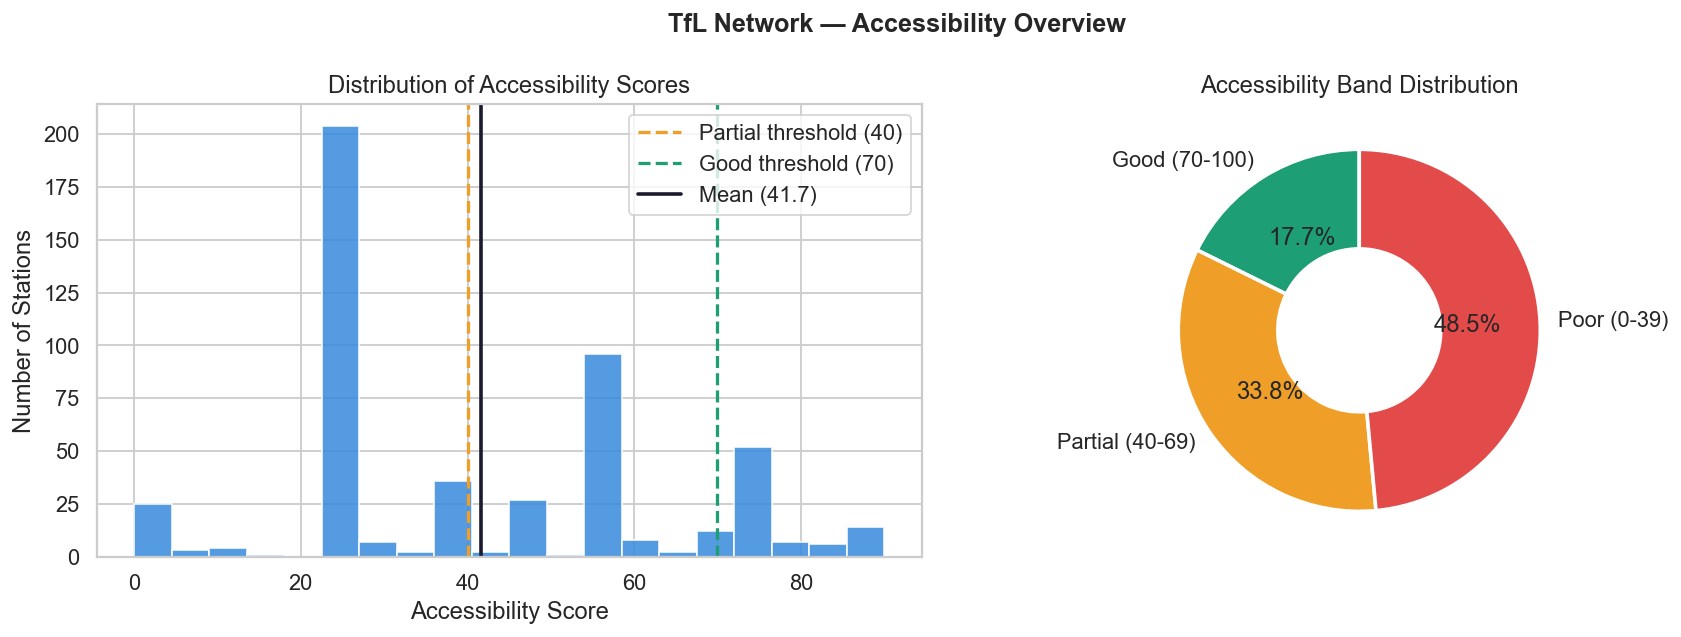

In [6]:
# ── Score distribution + band donut ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(master['AccessibilityScore'], bins=20,
             color='#378ADD', edgecolor='white', alpha=0.85)
axes[0].axvline(40, color=COLOURS['Partial (40-69)'], linestyle='--',
                linewidth=1.8, label='Partial threshold (40)')
axes[0].axvline(70, color=COLOURS['Good (70-100)'], linestyle='--',
                linewidth=1.8, label='Good threshold (70)')
axes[0].axvline(master['AccessibilityScore'].mean(), color='#1a1a2e',
                linewidth=2, label=f'Mean ({master["AccessibilityScore"].mean():.1f})')
axes[0].set_xlabel('Accessibility Score')
axes[0].set_ylabel('Number of Stations')
axes[0].set_title('Distribution of Accessibility Scores')
axes[0].legend()

band_vals = [master['AccessibilityBand'].value_counts().get(b, 0) for b in BAND_ORDER]
axes[1].pie(band_vals, labels=BAND_ORDER, colors=PALETTE, autopct='%1.1f%%',
            startangle=90, wedgeprops={'width': 0.55, 'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Accessibility Band Distribution')

plt.suptitle('TfL Network — Accessibility Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

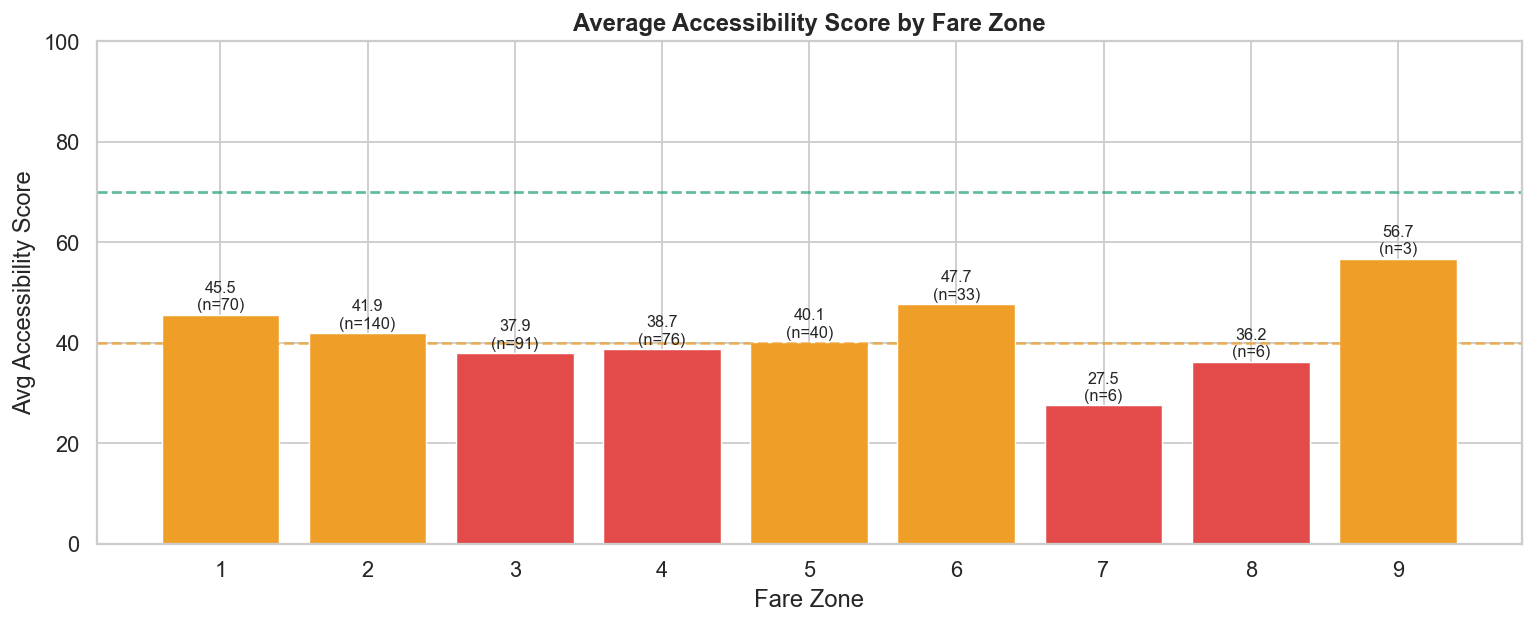

PrimaryZone  AvgScore  Count  LiftPct  ToiletPct
          1     45.55     70     0.43       0.26
          2     41.89    140     0.46       0.15
          3     37.86     91     0.40       0.16
          4     38.73     76     0.36       0.28
          5     40.14     40     0.32       0.32
          6     47.73     33     0.48       0.36
          7     27.50      6     0.00       0.00
          8     36.17      6     0.33       0.17
          9     56.67      3     0.67       0.33


In [7]:
# ── Average score by fare zone ──────────────────────────────────
zone_df = (master[master['PrimaryZone'] != 'Unknown']
           .groupby('PrimaryZone')
           .agg(AvgScore=('AccessibilityScore','mean'),
                Count=('Name','count'),
                LiftPct=('HasLift','mean'),
                ToiletPct=('HasAccessibleToilet','mean'))
           .reset_index().sort_values('PrimaryZone'))

bar_colours = zone_df['AvgScore'].apply(
    lambda s: COLOURS['Good (70-100)'] if s >= 70
    else (COLOURS['Partial (40-69)'] if s >= 40 else COLOURS['Poor (0-39)'])
)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(zone_df['PrimaryZone'], zone_df['AvgScore'].round(1),
              color=bar_colours, edgecolor='white', linewidth=0.8)
ax.axhline(40, color=COLOURS['Partial (40-69)'], linestyle='--', linewidth=1.5, alpha=0.7)
ax.axhline(70, color=COLOURS['Good (70-100)'],   linestyle='--', linewidth=1.5, alpha=0.7)
for bar, val, n in zip(bars, zone_df['AvgScore'], zone_df['Count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}\n(n={n})', ha='center', fontsize=9)
ax.set_xlabel('Fare Zone')
ax.set_ylabel('Avg Accessibility Score')
ax.set_title('Average Accessibility Score by Fare Zone', fontweight='bold')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

print(zone_df[['PrimaryZone','AvgScore','Count','LiftPct','ToiletPct']].round(2).to_string(index=False))

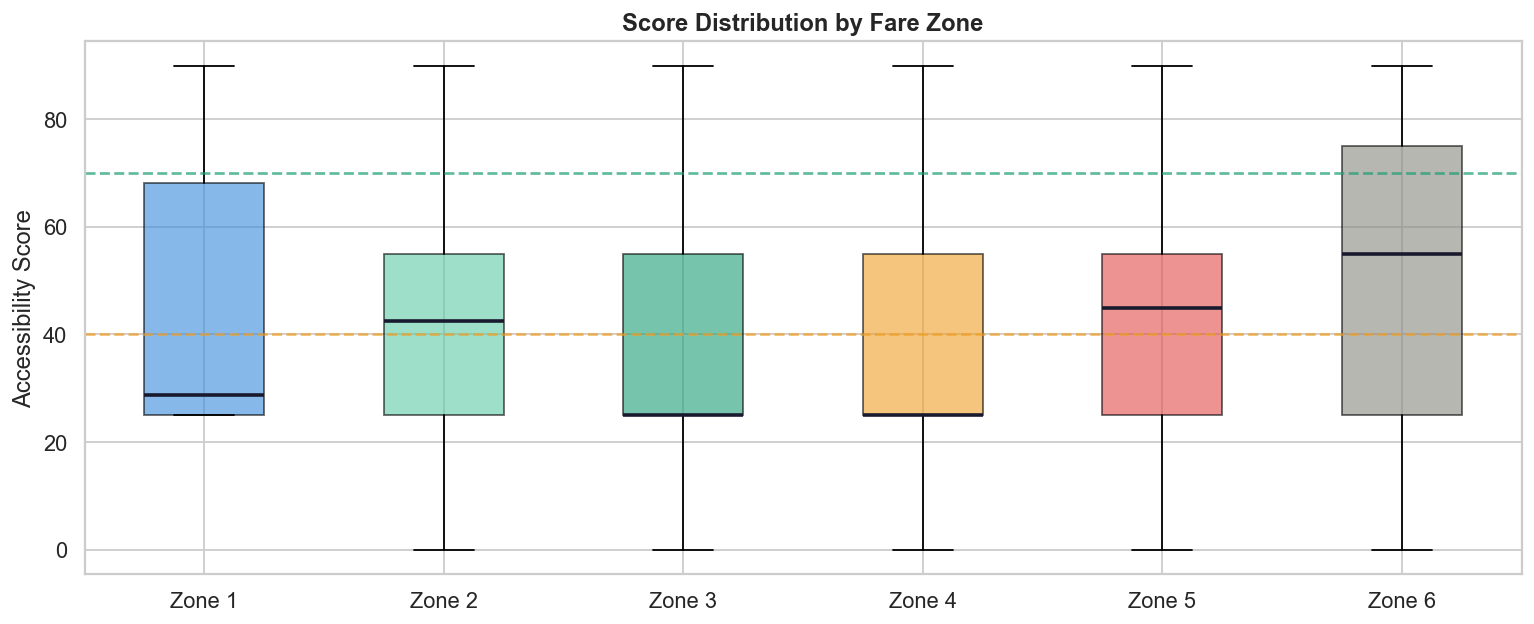

In [8]:
# ── Box plot: score spread by zone ──────────────────────────────
zone_data = master[master['PrimaryZone'].isin(['1','2','3','4','5','6'])]
groups    = [zone_data[zone_data['PrimaryZone']==z]['AccessibilityScore'].values
             for z in ['1','2','3','4','5','6']]

fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot(groups, labels=[f'Zone {z}' for z in range(1,7)],
                patch_artist=True,
                medianprops={'color':'#1a1a2e','linewidth':2})
box_colours = ['#378ADD','#5DCAA5','#1D9E75','#EF9F27','#E24B4A','#888780']
for patch, c in zip(bp['boxes'], box_colours):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax.axhline(40, color=COLOURS['Partial (40-69)'], linestyle='--', alpha=0.7)
ax.axhline(70, color=COLOURS['Good (70-100)'],   linestyle='--', alpha=0.7)
ax.set_ylabel('Accessibility Score')
ax.set_title('Score Distribution by Fare Zone', fontweight='bold')
plt.tight_layout()
plt.show()